# Thermodynamics and Physical Properties of Ammonia

This notebook explores the thermodynamic and physical properties of ammonia (NH₃)
using NeqSim. We cover:

1. **Phase diagram and vapor pressure curve**
2. **Density, enthalpy, and heat capacity** as functions of temperature and pressure
3. **Transport properties** — viscosity and thermal conductivity
4. **Phase envelope for ammonia-water system** (CPA EOS)
5. **Ammonia-hydrocarbon interactions**

## Background

Ammonia (NH₃) is increasingly important in the energy transition:
- **Energy carrier** for hydrogen (H₂ storage and transport)
- **Refrigerant** (natural working fluid, R-717)
- **Marine fuel** (zero-carbon shipping)
- **Power generation** (co-firing with natural gas)

| Property | Value |
|----------|-------|
| Molecular weight | 17.031 g/mol |
| Critical temperature | 132.4 °C |
| Critical pressure | 113.5 bara |
| Normal boiling point | -33.3 °C |
| Triple point | -77.7 °C |

Ammonia is a strongly polar molecule with hydrogen bonding. The CPA (Cubic Plus
Association) equation of state is recommended for accurate property prediction.

In [1]:
# Setup NeqSim
import subprocess, sys
try:
    from neqsim import jneqsim
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'neqsim'])
    from neqsim import jneqsim

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# NeqSim Java classes
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations

print('NeqSim loaded successfully')

NeqSim loaded successfully


## 1. Ammonia Vapor Pressure Curve

Calculate the saturation pressure of ammonia at different temperatures
and compare SRK vs CPA equations of state.

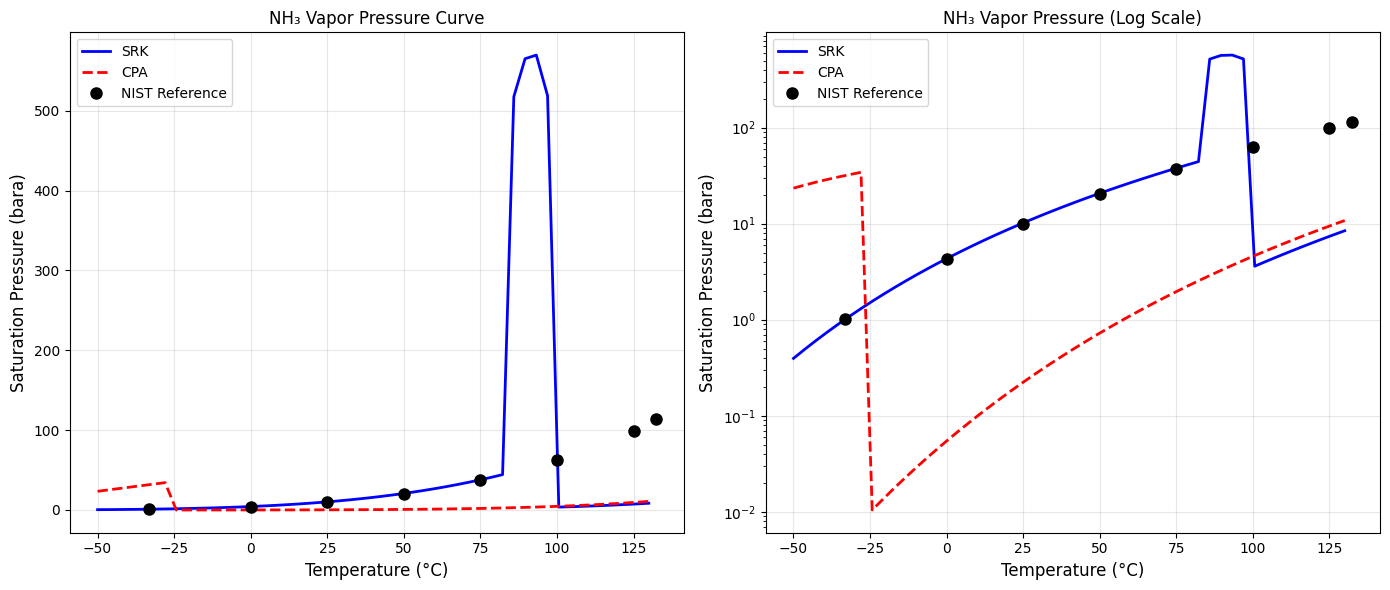

Figure saved: ammonia_vapor_pressure.png


In [2]:
# Vapor pressure curve for pure ammonia
temperatures_C = np.linspace(-50, 130, 50)

p_sat_srk = []
p_sat_cpa = []

for t in temperatures_C:
    # SRK EOS
    try:
        fluid_srk = SystemSrkEos(273.15 + float(t), 10.0)
        fluid_srk.addComponent('ammonia', 1.0)
        fluid_srk.setMixingRule('classic')
        ops_srk = ThermodynamicOperations(fluid_srk)
        ops_srk.bubblePointPressureFlash(False)
        p_sat_srk.append(fluid_srk.getPressure('bara'))
    except Exception:
        p_sat_srk.append(float('nan'))

    # CPA EOS
    try:
        fluid_cpa = SystemSrkCPAstatoil(273.15 + float(t), 10.0)
        fluid_cpa.addComponent('ammonia', 1.0)
        fluid_cpa.setMixingRule('classic')
        ops_cpa = ThermodynamicOperations(fluid_cpa)
        ops_cpa.bubblePointPressureFlash(False)
        p_sat_cpa.append(fluid_cpa.getPressure('bara'))
    except Exception:
        p_sat_cpa.append(float('nan'))

# Reference data (NIST)
nist_T = [-33.3, 0, 25, 50, 75, 100, 125, 132.4]
nist_P = [1.013, 4.29, 10.03, 20.33, 37.11, 62.53, 98.61, 113.5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Linear scale
ax1.plot(temperatures_C, p_sat_srk, 'b-', label='SRK', linewidth=2)
ax1.plot(temperatures_C, p_sat_cpa, 'r--', label='CPA', linewidth=2)
ax1.plot(nist_T, nist_P, 'ko', label='NIST Reference', markersize=8)
ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Saturation Pressure (bara)', fontsize=12)
ax1.set_title('NH₃ Vapor Pressure Curve')
ax1.legend()
ax1.grid(alpha=0.3)

# Log scale (Clausius-Clapeyron)
ax2.semilogy(temperatures_C, p_sat_srk, 'b-', label='SRK', linewidth=2)
ax2.semilogy(temperatures_C, p_sat_cpa, 'r--', label='CPA', linewidth=2)
ax2.semilogy(nist_T, nist_P, 'ko', label='NIST Reference', markersize=8)
ax2.set_xlabel('Temperature (°C)', fontsize=12)
ax2.set_ylabel('Saturation Pressure (bara)', fontsize=12)
ax2.set_title('NH₃ Vapor Pressure (Log Scale)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ammonia_vapor_pressure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: ammonia_vapor_pressure.png')

## 2. Density and Thermodynamic Properties

Calculate density, enthalpy, entropy, and heat capacity across a range of temperatures.

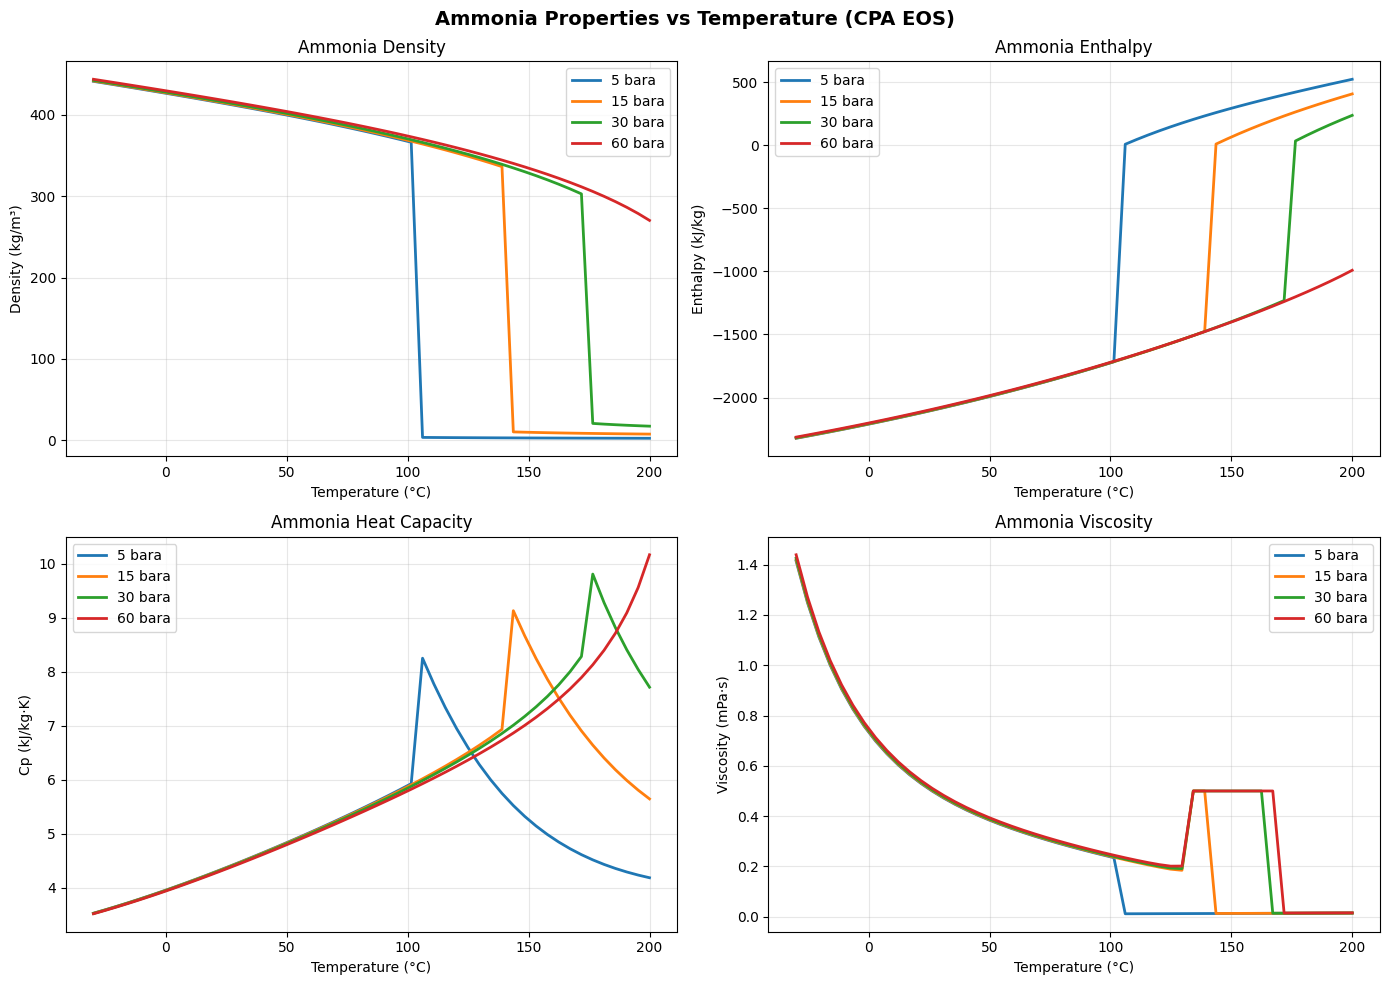

Figure saved: ammonia_properties.png


In [3]:
# Properties at various temperatures and pressures
pressures = [5.0, 15.0, 30.0, 60.0]
temps = np.linspace(-30, 200, 50)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for P in pressures:
    densities = []
    enthalpies = []
    cps = []
    viscosities = []

    for t in temps:
        try:
            fluid = SystemSrkCPAstatoil(273.15 + float(t), float(P))
            fluid.addComponent('ammonia', 1.0)
            fluid.setMixingRule('classic')
            ops = ThermodynamicOperations(fluid)
            ops.TPflash()
            fluid.initProperties()

            densities.append(fluid.getDensity('kg/m3'))
            enthalpies.append(fluid.getEnthalpy('kJ/kg'))
            cps.append(fluid.getCp('kJ/kgK'))
            viscosities.append(fluid.getPhase(0).getViscosity('kg/msec') * 1000)  # mPa.s
        except Exception:
            densities.append(float('nan'))
            enthalpies.append(float('nan'))
            cps.append(float('nan'))
            viscosities.append(float('nan'))

    label = f'{P:.0f} bara'
    axes[0, 0].plot(temps, densities, label=label, linewidth=2)
    axes[0, 1].plot(temps, enthalpies, label=label, linewidth=2)
    axes[1, 0].plot(temps, cps, label=label, linewidth=2)
    axes[1, 1].plot(temps, viscosities, label=label, linewidth=2)

axes[0, 0].set_xlabel('Temperature (°C)')
axes[0, 0].set_ylabel('Density (kg/m³)')
axes[0, 0].set_title('Ammonia Density')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('Enthalpy (kJ/kg)')
axes[0, 1].set_title('Ammonia Enthalpy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].set_xlabel('Temperature (°C)')
axes[1, 0].set_ylabel('Cp (kJ/kg·K)')
axes[1, 0].set_title('Ammonia Heat Capacity')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].set_xlabel('Temperature (°C)')
axes[1, 1].set_ylabel('Viscosity (mPa·s)')
axes[1, 1].set_title('Ammonia Viscosity')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Ammonia Properties vs Temperature (CPA EOS)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ammonia_properties.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: ammonia_properties.png')

## 3. Ammonia-Water System (VLE)

The ammonia-water system is critical for absorption refrigeration and scrubbing.
We use the CPA equation of state which captures the strong hydrogen-bonding
interactions between NH₃ and H₂O.

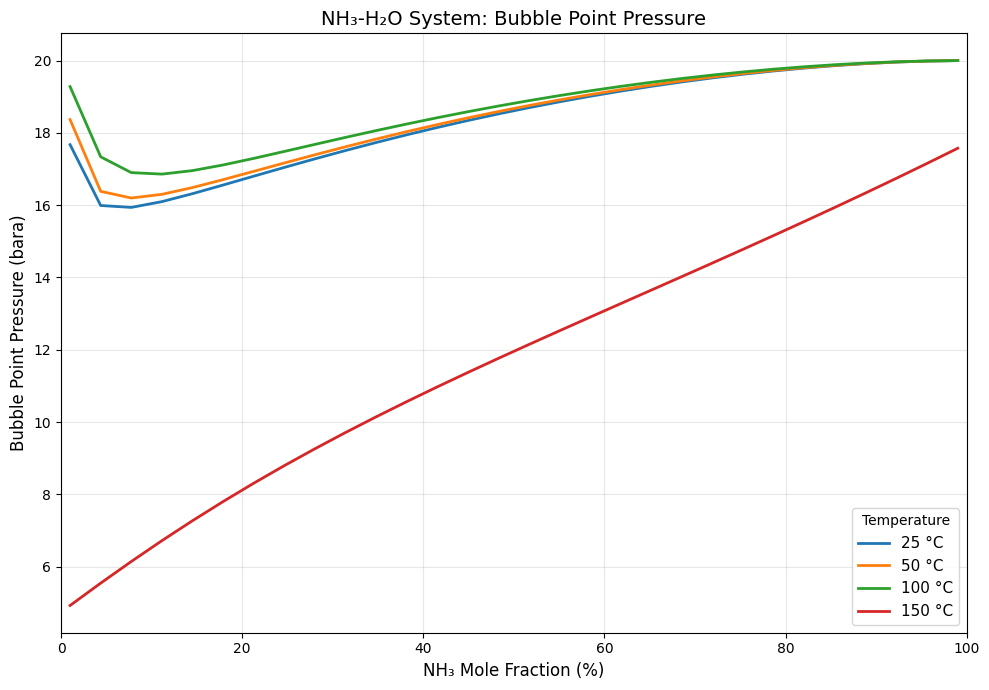

Figure saved: ammonia_water_vle.png


In [4]:
# Ammonia-Water VLE at different temperatures
nh3_fractions = np.linspace(0.01, 0.99, 30)
temps_vle = [25.0, 50.0, 100.0, 150.0]

fig, ax = plt.subplots(figsize=(10, 7))

for t_vle in temps_vle:
    bubble_p = []

    for x_nh3 in nh3_fractions:
        try:
            fluid_vle = SystemSrkCPAstatoil(273.15 + t_vle, 20.0)
            fluid_vle.addComponent('ammonia', float(x_nh3))
            fluid_vle.addComponent('water', float(1.0 - x_nh3))
            fluid_vle.setMixingRule('classic')

            ops_vle = ThermodynamicOperations(fluid_vle)
            ops_vle.bubblePointPressureFlash(False)
            bubble_p.append(fluid_vle.getPressure('bara'))
        except Exception:
            bubble_p.append(float('nan'))

    ax.plot(nh3_fractions * 100, bubble_p, linewidth=2, label=f'{t_vle:.0f} °C')

ax.set_xlabel('NH₃ Mole Fraction (%)', fontsize=12)
ax.set_ylabel('Bubble Point Pressure (bara)', fontsize=12)
ax.set_title('NH₃-H₂O System: Bubble Point Pressure', fontsize=14)
ax.legend(title='Temperature', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('ammonia_water_vle.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: ammonia_water_vle.png')

## 4. Properties Summary Table

Create a reference table of ammonia properties at key conditions.

In [5]:
# Properties at key conditions
conditions = [
    ('Storage (-33°C, 1 bar)', -33.0, 1.0),
    ('Ambient (25°C, 10 bar)', 25.0, 10.0),
    ('Transport (25°C, 17 bar)', 25.0, 17.0),
    ('High P (50°C, 30 bar)', 50.0, 30.0),
    ('Cracking inlet (500°C, 30 bar)', 500.0, 30.0),
]

rows = []
for name, t, p in conditions:
    fluid = SystemSrkCPAstatoil(273.15 + t, p)
    fluid.addComponent('ammonia', 1.0)
    fluid.setMixingRule('classic')

    ops = ThermodynamicOperations(fluid)
    ops.TPflash()
    fluid.initProperties()

    phase_type = 'Gas' if fluid.hasPhaseType('gas') and not fluid.hasPhaseType('oil') else 'Liquid' if not fluid.hasPhaseType('gas') else 'Two-phase'

    rows.append({
        'Condition': name,
        'T (°C)': t,
        'P (bara)': p,
        'Phase': phase_type,
        'Density (kg/m³)': round(fluid.getDensity('kg/m3'), 1),
        'Cp (kJ/kgK)': round(fluid.getCp('kJ/kgK'), 3),
        'Z': round(fluid.getZ(), 4),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

                     Condition  T (°C)  P (bara)  Phase  Density (kg/m³)  Cp (kJ/kgK)      Z
        Storage (-33°C, 1 bar)   -33.0       1.0 Liquid            442.6        3.489 0.0019
        Ambient (25°C, 10 bar)    25.0      10.0 Liquid            414.0        4.370 0.0166
      Transport (25°C, 17 bar)    25.0      17.0 Liquid            414.5        4.366 0.0282
         High P (50°C, 30 bar)    50.0      30.0 Liquid            401.9        4.815 0.0473
Cracking inlet (500°C, 30 bar)   500.0      30.0    Gas              8.1        4.778 0.9838


## Summary

This notebook demonstrated calculation of ammonia properties using NeqSim:

- **CPA EOS** is recommended for ammonia due to strong hydrogen bonding
- Vapor pressure curve agrees well with NIST reference data
- NH₃-H₂O system can be modeled for absorption refrigeration applications
- Properties at key conditions for storage, transport, and cracking are tabulated

### Key Points
- Ammonia boils at -33.3°C at atmospheric pressure (similar to propane at -42°C)
- Critical point at 132.4°C, 113.5 bara — well above typical storage conditions
- Strong NH₃-H₂O interactions require CPA or electrolyte models

### Related Notebooks
- Ammonia as a Refrigerant
- Ammonia Cracking for Hydrogen Production
- Thermodynamics of Water and Ammonia